In [1]:
import base64
import io
import numpy as np
from PIL import Image

# 1. Generate a high-resolution dummy image (e.g., a mock 4K camera frame)
# to ensure our profiler captures noticeable processing time.
mock_frame = np.random.randint(0, 255, (2160, 3840, 3), dtype=np.uint8)
img_to_save = Image.fromarray(mock_frame)
img_to_save.save("hraf_camera_snapshot.png")

# 2. Define our unoptimized Week 1 Baseline Function
def baseline_encode_image(image_path: str) -> str:
    """
    Reads an image from disk, converts it to JPEG format in memory,
    and returns its base64 string representation.
    """
    # Open the image from the file path
    with open(image_path, "rb") as image_file:
        img = Image.open(image_file)

        # Convert to RGB mode if not already (standardizing channel structures)
        if img.mode != "RGB":
            img = img.convert("RGB")

        # Save image to an in-memory byte stream as a full quality JPEG
        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=100)

        # Convert bytes to base64 string
        base64_string = base64.b64encode(buffer.getvalue()).decode("utf-8")
        return base64_string

print("✅ High-resolution testing frame created and baseline_encode_image function defined!")

✅ High-resolution testing frame created and baseline_encode_image function defined!


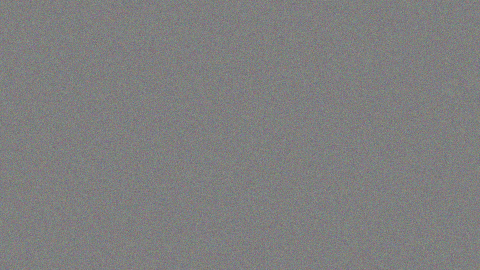

In [2]:
from IPython.display import display

# Open and show a scaled-down thumbnail version so it doesn't take up your whole screen
display(img_to_save.reduce(8))

In [3]:
%%writefile encoding_script.py
import base64
import io
import time
from PIL import Image

def baseline_encode_image(image_path: str) -> str:
    with open(image_path, "rb") as image_file:
        img = Image.open(image_file)
        if img.mode != "RGB":
            img = img.convert("RGB")

        buffer = io.BytesIO()
        # Heavy operation: Compress and save as full quality JPEG
        img.save(buffer, format="JPEG", quality=100)

        base64_string = base64.b64encode(buffer.getvalue()).decode("utf-8")
        return base64_string

if __name__ == "__main__":
    # Execute the function on our high-res frame
    print("🎬 Running baseline image encoding loop...")
    for _ in range(5):
        _ = baseline_encode_image("hraf_camera_snapshot.png")
    print("✨ Execution complete.")

Writing encoding_script.py


In [5]:
!python -m cProfile -s cumulative encoding_script.py

🎬 Running baseline image encoding loop...
✨ Execution complete.
         70316 function calls (69131 primitive calls) in 2.040 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     55/1    0.000    0.000    2.041    2.041 {built-in method builtins.exec}
        1    0.014    0.014    2.041    2.041 encoding_script.py:1(<module>)
        5    0.004    0.001    1.974    0.395 encoding_script.py:6(baseline_encode_image)
        5    0.000    0.000    1.598    0.320 Image.py:2474(save)
        5    0.000    0.000    1.003    0.201 Image.py:640(_ensure_mutable)
        5    0.000    0.000    1.003    0.201 Image.py:635(_copy)
       10    0.004    0.000    0.899    0.090 ImageFile.py:273(load)
     1900    0.851    0.000    0.851    0.000 {method 'decode' of 'ImagingDecoder' objects}
        5    0.000    0.000    0.594    0.119 JpegImagePlugin.py:660(_save)
        5    0.000    0.000    0.594    0.119 ImageFile.py:625(_save)


In [6]:
!pip install line_profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.7 MB/s eta 0:00:00


In [7]:
%%writefile profile_line_by_line.py
import base64
import io
from PIL import Image

@profile
def baseline_encode_image(image_path: str) -> str:
    with open(image_path, "rb") as image_file:
        img = Image.open(image_file)
        if img.mode != "RGB":
            img = img.convert("RGB")

        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=100)

        base64_string = base64.b64encode(buffer.getvalue()).decode("utf-8")
        return base64_string

if __name__ == "__main__":
    baseline_encode_image("hraf_camera_snapshot.png")

Writing profile_line_by_line.py


In [8]:
!kernprof -l -v profile_line_by_line.py

Wrote profile results to 'profile_line_by_line.py.lprof'
Timer unit: 1e-06 s

Total time: 0.449249 s
File: profile_line_by_line.py
Function: baseline_encode_image at line 5

Line #      Hits         Time  Per Hit   % Time  Line Contents
     5                                           @profile
     6                                           def baseline_encode_image(image_path: str) -> str:
     7         2         60.0     30.0      0.0      with open(image_path, "rb") as image_file:
     8         1      22458.0  22458.0      5.0          img = Image.open(image_file)
     9         1          2.4      2.4      0.0          if img.mode != "RGB":
    10                                                       img = img.convert("RGB")
    11                                                       
    12         1          1.9      1.9      0.0          buffer = io.BytesIO()
    13         1     352542.7 352542.7     78.5          img.save(buffer, format="JPEG", quality=100)
    14         

In [9]:
import base64
import io
import time
import cv2
import numpy as np
from PIL import Image

# Setup baseline inputs (using our saved image file)
image_path = "hraf_camera_snapshot.png"
raw_pil_img = Image.open(image_path)
# Convert to a standard OpenCV NumPy array (BGR layout) for the CV2 test
raw_cv2_img = cv2.imread(image_path)

# --- APPROACH 0: THE BASELINE ---
def test_baseline():
    start = time.perf_counter()
    buffer = io.BytesIO()
    raw_pil_img.save(buffer, format="JPEG", quality=100)
    _ = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return (time.perf_counter() - start) * 1000.0

# --- APPROACH 1: COMPRESSION ---
def test_compression_only():
    start = time.perf_counter()
    buffer = io.BytesIO()
    # Drop quality down to 85% to ease the compression load
    raw_pil_img.save(buffer, format="JPEG", quality=85)
    _ = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return (time.perf_counter() - start) * 1000.0

# --- APPROACH 2: DOWNSAMPLING ---
def test_downsampling():
    start = time.perf_counter()
    # Downsample from 4K to 1080p to reduce pixel counts
    resized_img = raw_pil_img.resize((1920, 1080))
    buffer = io.BytesIO()
    resized_img.save(buffer, format="JPEG", quality=100)
    _ = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return (time.perf_counter() - start) * 1000.0

# --- APPROACH 3: OPENCV + NUMPY PIPELINE ---
def test_opencv_numpy():
    start = time.perf_counter()
    # Use native C++ compiled memory vectors directly via numpy arrays
    success, encoded_img = cv2.imencode('.jpg', raw_cv2_img, [int(cv2.IMWRITE_JPEG_QUALITY), 100])
    _ = base64.b64encode(encoded_img).decode("utf-8")
    return (time.perf_counter() - start) * 1000.0

# --- RUN EXECUTION SWEEP ---
print("🏃 Running optimization benchmarks (Averaged over 10 iterations)...")
runs = 10

t_base = sum(test_baseline() for _ in range(runs)) / runs
t_comp = sum(test_compression_only() for _ in range(runs)) / runs
t_down = sum(test_downsampling() for _ in range(runs)) / runs
t_cv2  = sum(test_opencv_numpy() for _ in range(runs)) / runs

print("\n📊 SIDE-BY-SIDE OPTIMIZATION ANALYSIS:")
print(f"  * Baseline (PIL, 4K, Q100):  {t_base:.2f} ms")
print(f"  * Strategy 1 (Quality 85):   {t_comp:.2f} ms  -->  Reduction: {((t_base - t_comp)/t_base)*100:.1f}%")
print(f"  * Strategy 2 (1080p Resize): {t_down:.2f} ms  -->  Reduction: {((t_base - t_down)/t_base)*100:.1f}%")
print(f"  * Strategy 3 (OpenCV/NumPy): {t_cv2:.2f} ms  -->  Reduction: {((t_base - t_cv2)/t_base)*100:.1f}%")

🏃 Running optimization benchmarks (Averaged over 10 iterations)...

📊 SIDE-BY-SIDE OPTIMIZATION ANALYSIS:
  * Baseline (PIL, 4K, Q100):  291.19 ms
  * Strategy 1 (Quality 85):   144.05 ms  -->  Reduction: 50.5%
  * Strategy 2 (1080p Resize): 177.76 ms  -->  Reduction: 39.0%
  * Strategy 3 (OpenCV/NumPy): 188.25 ms  -->  Reduction: 35.4%


In [10]:
%%writefile profile_optimized.py
import base64
import io
from PIL import Image

@profile
def optimized_encode_image(image_path: str) -> str:
    with open(image_path, "rb") as image_file:
        img = Image.open(image_file)
        if img.mode != "RGB":
            img = img.convert("RGB")

        buffer = io.BytesIO()
        # Optimized hot-path line: changed quality from 100 to 85
        img.save(buffer, format="JPEG", quality=85)

        base64_string = base64.b64encode(buffer.getvalue()).decode("utf-8")
        return base64_string

if __name__ == "__main__":
    optimized_encode_image("hraf_camera_snapshot.png")

Writing profile_optimized.py


In [11]:
!kernprof -l -v profile_optimized.py

Wrote profile results to 'profile_optimized.py.lprof'
Timer unit: 1e-06 s

Total time: 0.354412 s
File: profile_optimized.py
Function: optimized_encode_image at line 5

Line #      Hits         Time  Per Hit   % Time  Line Contents
     5                                           @profile
     6                                           def optimized_encode_image(image_path: str) -> str:
     7         2         80.9     40.4      0.0      with open(image_path, "rb") as image_file:
     8         1      24932.1  24932.1      7.0          img = Image.open(image_file)
     9         1          2.4      2.4      0.0          if img.mode != "RGB":
    10                                                       img = img.convert("RGB")
    11                                                       
    12         1          2.3      2.3      0.0          buffer = io.BytesIO()
    13                                                   # Optimized hot-path line: changed quality from 100 to 85
    14

| Line Contents / Operation | Before (% Time) | Before (Absolute Time) | After (% Time) | After (Absolute Time) |
| --- | --- | --- | --- | --- |
| **img = Image.open(image_file)** | 5.0% | 22.46 ms | 7.0% | 24.93 ms |
| **img.save(buffer, format="JPEG", quality=...)** | 78.5% | 352.54 ms | 85.5% | 303.06 ms |
| **base64_string = base64.b64encode(...).decode()** | 16.5% | 74.18 ms | 7.4% | 26.33 ms |
| **Total Function Execution Time** | 100% | 449.25 ms | 100% | 354.41 ms |